In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

from george import kernels
import george
from astropy.io import fits
from functions import *
from gp_model_params import info
from glob import glob
from gp_model_params import info

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
np.load('/Users/somayeh/Downloads/roman_times.npy')+8234 

array([2466580.50546065, 2466580.51598704, 2466580.52651343, ...,
       2468293.2203908 , 2468293.2309171 , 2468293.2414435 ])

In [3]:
from pathlib import Path
home = str(Path.home())

In [4]:
# Read and apply Roman noise function
noise_fun = noise_function('cycle6_snr_curve.txt')

In [184]:
tp = 'ELL'
direc = home+'/Downloads/Bulge_Variables/%s/'%tp
direc_list = np.sort(glob(direc+'*.fits'))
list_periods = np.genfromtxt(home+'/Downloads/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp)
                            , dtype='str')

In [185]:
# Read Roman time sampling
t_new = np.loadtxt('lc_example/ulwdc1_208_W149.txt', usecols=0)
t_new = t_new - min(t_new)

In [200]:
info[tp]['p0'][1] = 0.1
info[tp]['n_phs'] = 10
info[tp]['gp_opt_s_param'] =.5
info[tp]['fit_binned'] = False

In [201]:
info[tp]

{'kernel': CosineKernel(log_period=-1.0, ndim=1, axes=array([0])) + Matern32Kernel(metric=Metric(1.1051709180756477, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None),
 'p0': [-1.0, 0.1],
 'n_phs': 10,
 'p_range': [0.001, 10],
 'fit_binned': False,
 'gp_opt': True,
 'p0_period': <function gp_model_params.<lambda>(x)>,
 'example': 'OGLE-BLG-ELL-000008',
 'exp_period': 0.2130577,
 'gp_opt_s_param': 0.5}

In [202]:
for path in direc_list[9:10]:
    
    ID = path.split('/')[-1].split('_')[0]
    print(ID)
    period = float(list_periods[list_periods[:, 0] == ID][0][1])
    period, df = read_fits(path, period=period,
                           tp = tp)
    if np.isnan(period):
        pass
    df = df[df.band=='I']
    df_modified = gap_reducer(df, period)
    gp = prep_gp(info[tp], period)
    x, y, e, X = prep_input(df_modified, tp, period)
    y_median = np.median(y)
    gp, xfit, yfit, nll_opt = fit_gp(x, y, e, info[tp], gp)
    print(nll_opt)
    # regular sampling in Roman observing window
    t_prime = X
    df_roman, t_prime_new,  mu_new,mu, std = predict_gp(gp, 
                                                        yfit, 
                                                        y_median, 
                                                        t_prime, 
                                                        t_new, 
                                                        info[tp], 
                                                        period, 
                                                        noise_fun)
    

    
    

OGLE-BLG-ELL-001683
1200.386512606975


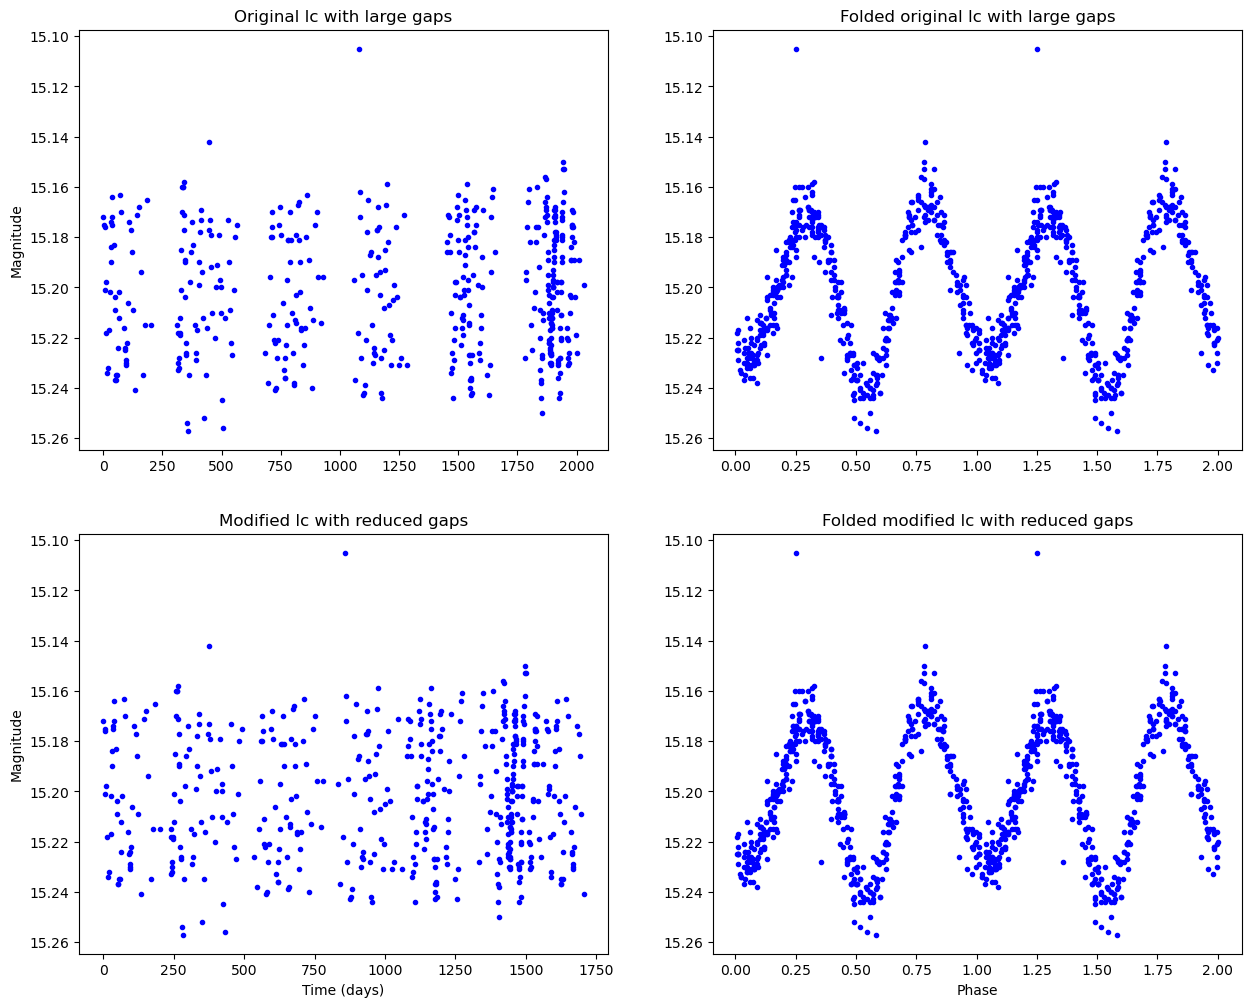

In [203]:
fig, axs = plt.subplots(2, 2)




axs[0,0].plot(df.t, df.m,'b.')
axs[0,1].plot(df.phase, df.m,'b.')
axs[0,1].plot(df.phase+1, df.m,'b.')

axs[1,0].plot(df_modified.t, df_modified.m,'b.')
axs[1,1].plot(df_modified.phase, df_modified.m,'b.')
axs[1,1].plot(df_modified.phase+1, df_modified.m,'b.')



axs[0,0].invert_yaxis()
axs[0,1].invert_yaxis()
axs[1,1].invert_yaxis()
axs[1,0].invert_yaxis()

axs[0,0].set_ylabel('Magnitude')
axs[0,0].set_title('Original lc with large gaps')
axs[0,1].set_title('Folded original lc with large gaps')
axs[1,0].set_ylabel('Magnitude')
axs[1,0].set_title('Modified lc with reduced gaps')
axs[1,1].set_title('Folded modified lc with reduced gaps')

axs[1,0].set_xlabel('Time (days)')
axs[1,1].set_xlabel('Phase')




fig = plt.gcf()
fig.set_size_inches(15.0,12.0)

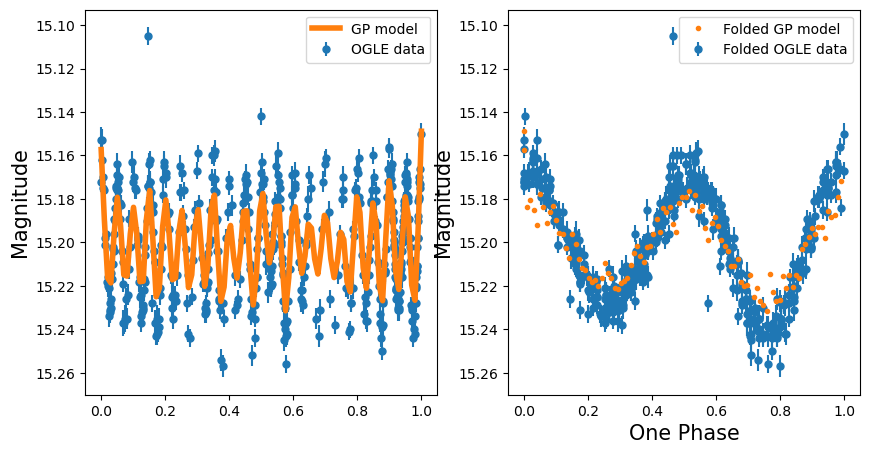

In [204]:
fig, axs = plt.subplots(1,2, figsize=(10, 5))
if np.isinf(info[tp]['n_phs']):
    tmp_period = period
else:
    tmp_period = 1/info[tp]['n_phs']
    
axs[0].errorbar(x, y,yerr=e, fmt = '.', ms = 10, label = 'OGLE data')

# axs[0].plot(bin_middles, bin_means, '.', zorder=11, label = 'Binned OGLE data')
axs[0].plot(t_prime,mu+y_median, linewidth = 4, label='GP model', zorder=11)
# axs[0].set_xlabel('%i Phases'%info[tp]['n_phs'], size=15)
axs[0].set_ylabel('Magnitude', size=15)
axs
axs[0].legend()
axs[0].invert_yaxis()

axs[1].errorbar((x/tmp_period)%1, y,yerr=e, fmt = '.', ms = 10, label = 'Folded OGLE data')

# axs[1].plot((bin_middles/tmp_period)%1, bin_means, '.', zorder=11, label='Binned OGLE data')
axs[1].plot((t_prime/tmp_period)%1,mu+y_median,'.', linewidth = 4, label='Folded GP model', zorder=11)
axs[1].set_xlabel('One Phase', size=15)
axs[1].set_ylabel('Magnitude', size=15)
axs[1].legend()
axs[1].invert_yaxis()

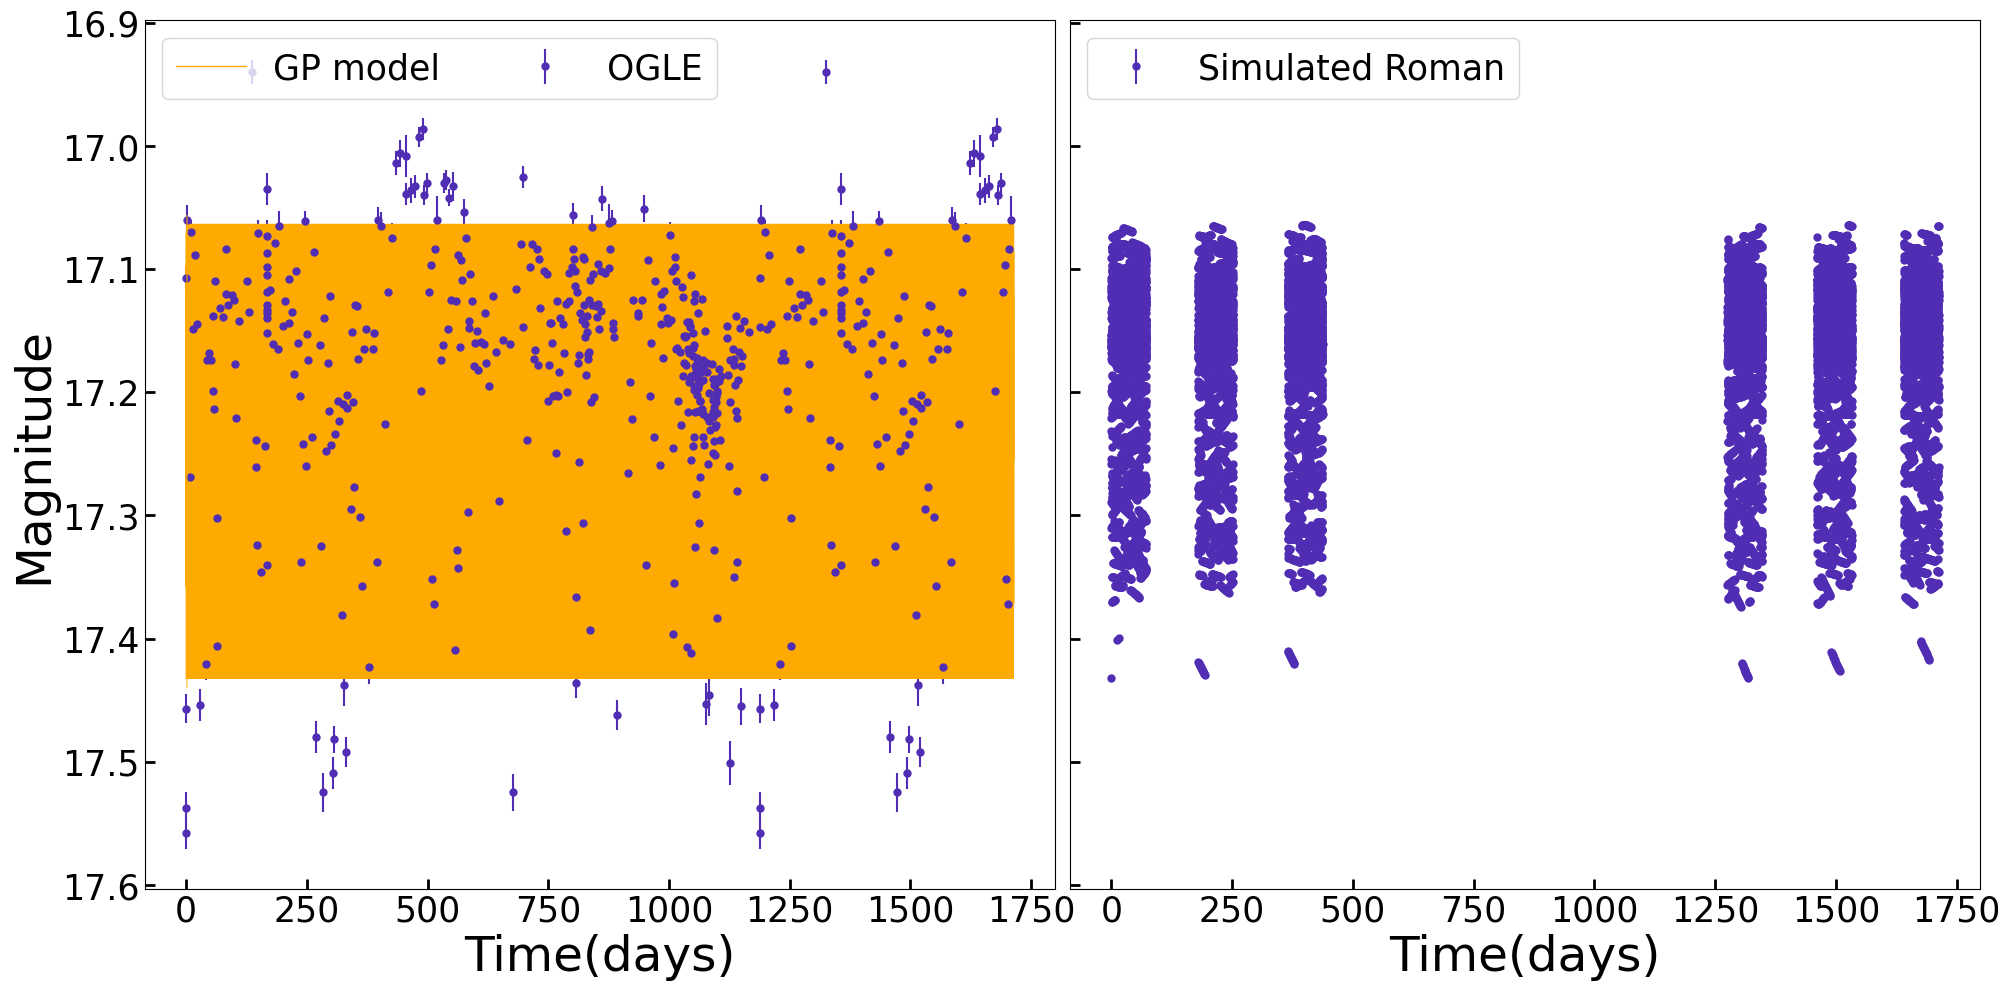

In [165]:
fig, ax = plt.subplots(1,2,figsize=(20,10), sharey=True)

data_color = '#502db3'
gp_color = '#ffaa00'

ax[0].errorbar(df_modified.t, 
               df_modified.m,
               yerr=df_modified.e, 
               fmt = '.', 
               ms=10, 
               color = data_color,
               label='OGLE')
ax[0].plot(t_prime_new, 
           mu_new+y_median, 
           color = gp_color,
           label='GP model', 
           linewidth=1)
ax[0].fill_between(t_prime, 
                   mu+y_median-std, 
                   mu+y_median+std, 
                   color = gp_color,
                   alpha=0.5,
                  zorder=11)

ax[0].set_xlabel('Time(days)', size=35)
ax[0].set_ylabel('Magnitude', size=35)
# plt.title(info.ID[i], size=25)
ax[0].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[0].legend(loc = 2, ncols=2, prop={'size':25})


ax[1].errorbar(df_roman.t, 
               df_roman.m+y_median,
               yerr=df_roman.e, 
               color = data_color,
               fmt = '.', 
               ms=10, 
               label='Simulated Roman')
ax[1].set_xlabel('Time(days)', size=35)
ax[1].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[1].legend(loc = 2,prop={'size':25})
fig.tight_layout()
ax[0].invert_yaxis()
# plt.savefig('OGLE_%s_full_lc_to_Roman_with_GP_model.jpg'%tp,facecolor='white', edgecolor='none', bbox_inches='tight')

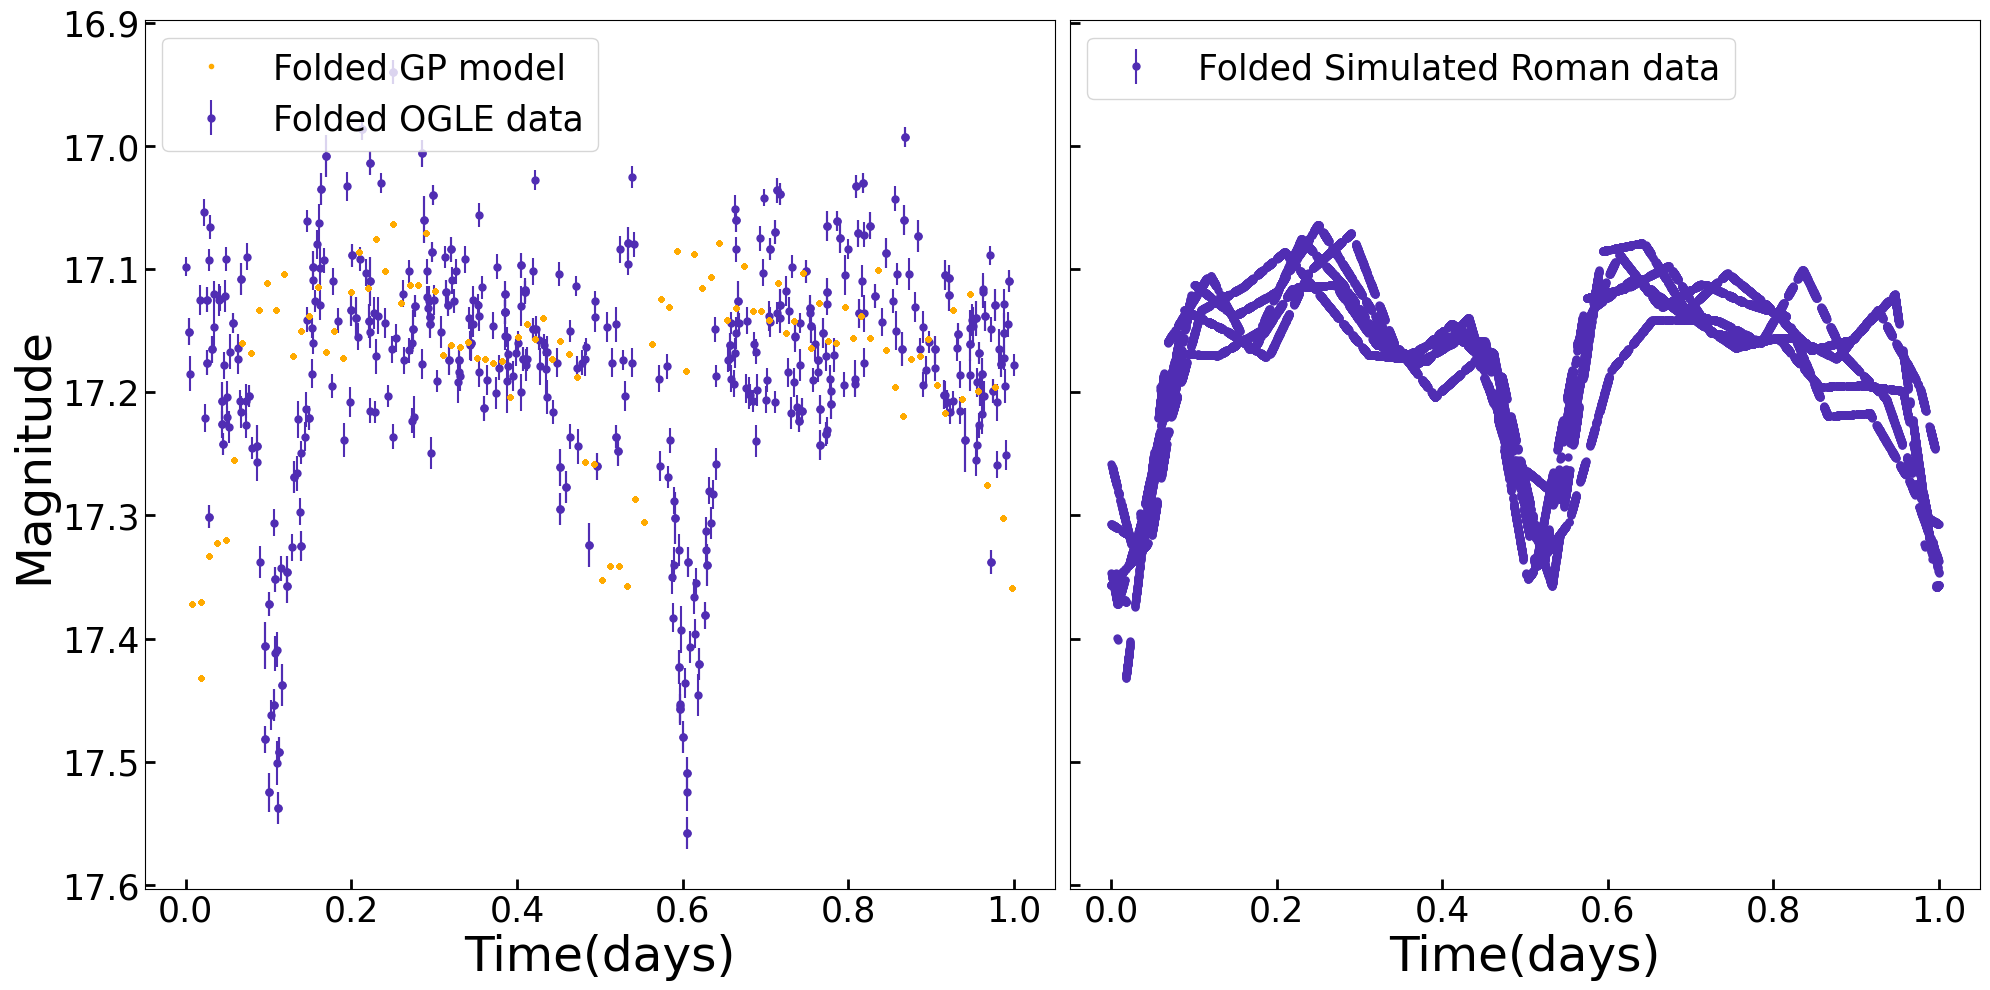

In [166]:
fig, ax = plt.subplots(1,2,figsize=(20,10), sharey=True)

t_prime_phase = T_0_fixer(t_prime_new, 
                          mu_new,
                          period, 
                          (t_prime_new/period)%1)
t_Roman_phase = T_0_fixer(df_roman.t.values, 
                          df_roman.m.values,
                          period, 
                          (df_roman.t.values/period)%1)

ax[0].errorbar(df_modified.phase, 
               df_modified.m,
               yerr=df_modified.e, 
               color = data_color,
               fmt = '.', 
               ms=10, 
               label='Folded OGLE data')
ax[0].plot(t_prime_phase[np.argsort(t_prime_phase)], 
           mu_new[np.argsort(t_prime_phase)]+y_median, 
           '.',
           color = gp_color,
           label='Folded GP model', 
           zorder=11)
ax[0].set_xlabel('Time(days)', size=35)
ax[0].set_ylabel('Magnitude', size=35)
ax[0].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[0].legend(loc = 2,prop={'size':25})


ax[1].errorbar(t_Roman_phase, 
               df_roman.m+y_median,
               yerr=df_roman.e, 
               fmt = '.', 
               color = data_color,
               ms=10, 
               label='Folded Simulated Roman data')
ax[1].set_xlabel('Time(days)', size=35)
ax[1].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[1].legend(loc = 2,prop={'size':25})
fig.tight_layout()
ax[0].invert_yaxis()
# plt.savefig('OGLE_%s_folded_lc_to_Roman_with_GP_model.jpg'%tp,facecolor='white', edgecolor='none', bbox_inches='tight')